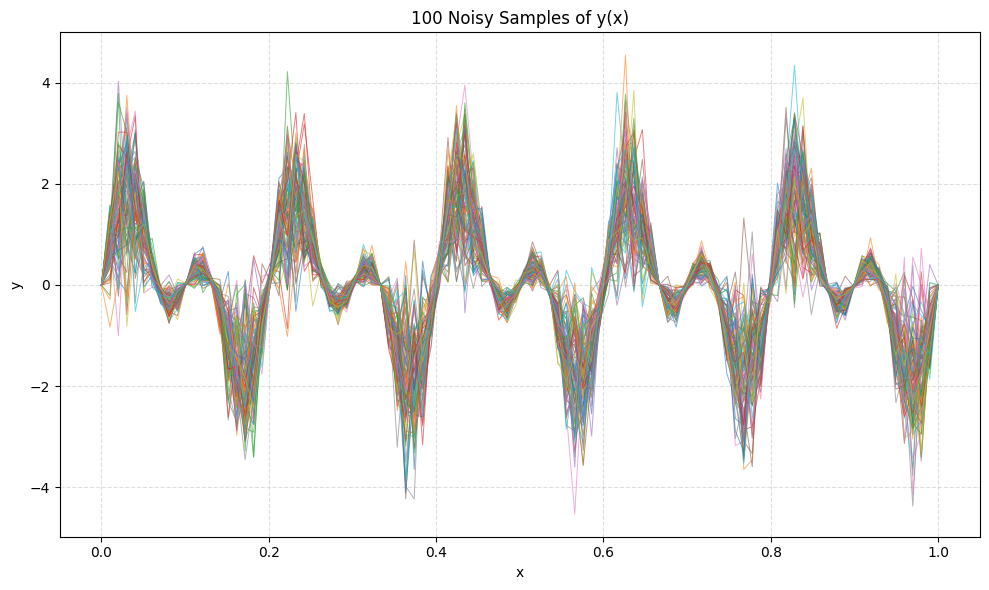

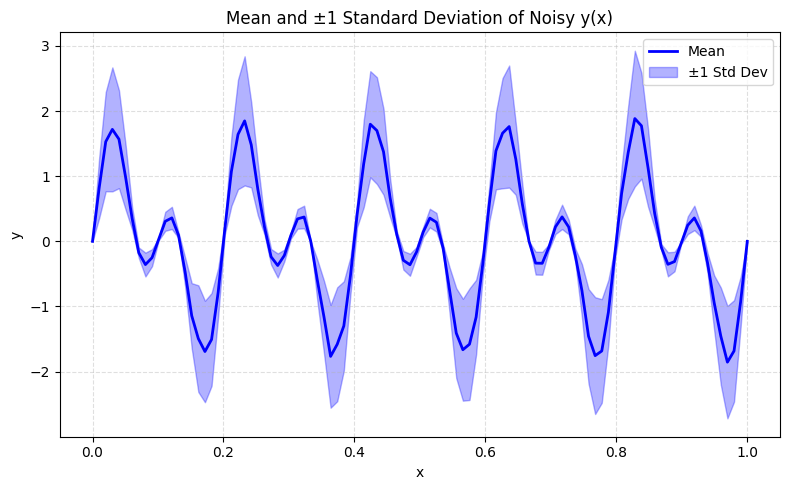

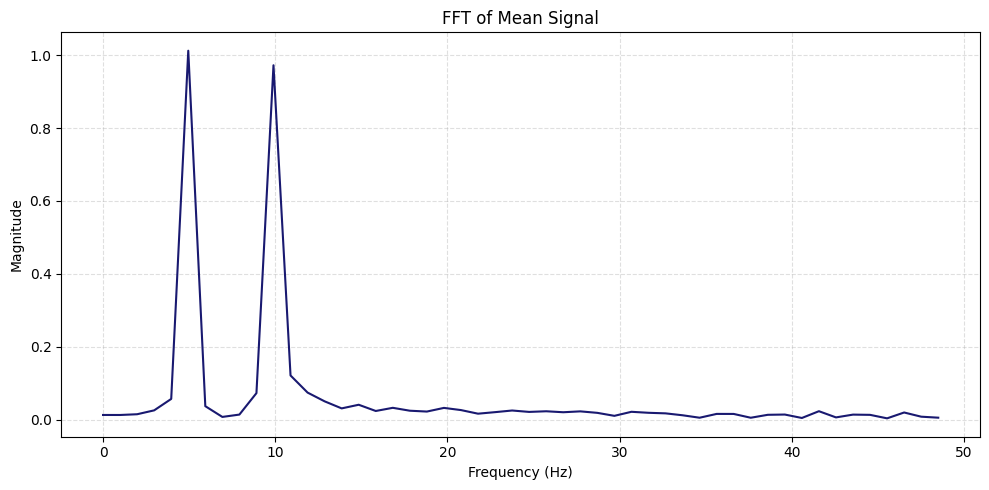

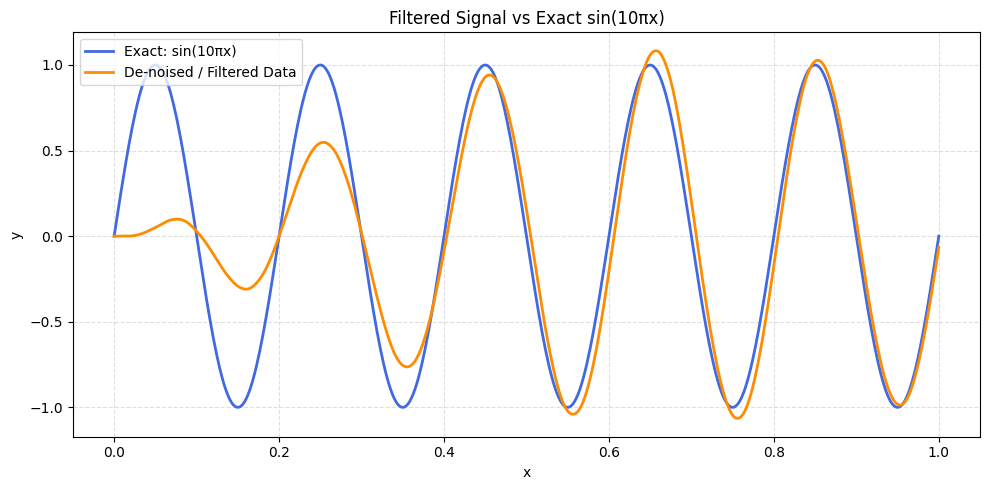

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import butter, lfilter

x_vals = np.linspace(0, 1, 100)
true_function = np.sin(10 * np.pi * x_vals) + np.sin(20 * np.pi * x_vals)
samples = 100
data_with_noise = np.zeros((samples, len(x_vals)))

for i in range(samples):
    stddev = np.abs(true_function) / 2
    noise = np.random.normal(0, stddev)
    data_with_noise[i] = true_function + noise

plt.figure(figsize=(10, 6))
for i in range(samples):
    plt.plot(x_vals, data_with_noise[i], linewidth=0.7, alpha=0.6)
plt.title("100 Noisy Samples of y(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_vals, mean_signal, color='blue', linewidth=2, label='Mean')
plt.fill_between(x_vals, mean_signal - std_dev, mean_signal + std_dev,
                 color='blue', alpha=0.3, label='±1 Std Dev')
plt.title("Mean and ±1 Standard Deviation of Noisy y(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

N = len(x_vals)
dx = (x_vals[-1] - x_vals[0]) / (N - 1)
frequencies = fftfreq(N, d=dx)[:N//2]
fft_result = fft(mean_signal)

plt.figure(figsize=(10, 5))
plt.plot(frequencies, 2.0 / N * np.abs(fft_result[:N//2]), color='midnightblue')
plt.title("FFT of Mean Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

N_fine = 500
x_fine = np.linspace(0, 1, N_fine)
target_wave = np.sin(10 * np.pi * x_fine)
noise_level = 0.5
noisy_signals = target_wave + noise_level * np.random.randn(100, N_fine)

sample_rate = 1 / (x_fine[1] - x_fine[0])
nyquist = sample_rate / 2
lowcut = 4 / nyquist
highcut = 6 / nyquist

b, a = butter(N=2, Wn=[lowcut, highcut], btype='band')
noisy_input = noisy_signals[0]
filtered_output = lfilter(b, a, noisy_input)

plt.figure(figsize=(10, 5))
plt.plot(x_fine, target_wave, label="Exact: sin(10πx)", color='royalblue', linewidth=2)
plt.plot(x_fine, filtered_output, label="De-noised / Filtered Data", color='darkorange', linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Filtered Signal vs Exact sin(10πx)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()